In [70]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D

In [71]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [72]:
from sklearn.model_selection import train_test_split
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.1, random_state=42)

In [73]:
train_images.shape

(45000, 32, 32, 3)

In [74]:
train_labels = to_categorical(train_labels, 10)
val_labels = to_categorical(val_labels, 10)
test_labels = to_categorical(test_labels, 10)

In [75]:
data_generator = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.12,
    height_shift_range=0.12,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    shear_range=10,
    channel_shift_range=0.1,
)

In [79]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
def create_resnet_transfer_model():
    inputs = layers.Input(shape=(32, 32, 3))

    x = layers.Resizing(224, 224)(inputs)

    x = layers.Lambda(preprocess_input)(x)

    base_model = ResNet50(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    # Custom classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Flatten()(x)
    x = layers.Dense(1024, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.Dense(512, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.Dense(256, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="CIFAR_ResNet50_Transfer")
    return model

model = create_resnet_transfer_model()

In [80]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
model.summary()

Model: "CIFAR_ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_4 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,345,610 (100.50 MB)

 Trainable params: 2,757,386 (10.52 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [82]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='resnet_cifar_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='resnet_cifar.weights.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

In [83]:
history = model.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8349 - loss: 0.4922
Epoch 1: val_accuracy improved from None to 0.87560, saving model to resnet_cifar_model.keras

Epoch 1: finished saving model to resnet_cifar_model.keras

Epoch 1: val_accuracy improved from None to 0.87560, saving model to resnet_cifar.weights.h5

Epoch 1: finished saving model to resnet_cifar.weights.h5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 190s 124ms/step - accuracy: 0.8661 - loss: 0.3947 - val_accuracy: 0.8756 - val_loss: 0.3706 - learning_rate: 0.0010
Epoch 2/10
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9032 - loss: 0.2849
Epoch 2: val_accuracy improved from 0.87560 to 0.89700, saving model to resnet_cifar_model.keras

Epoch 2: finished saving model to resnet_cifar_model.keras

Epoch 2: val_accuracy improved from 0.87560 to 0.89700, saving model to resnet_cifar.weights.h5

Epoch 2: finished saving model to resnet_cifar.weights.h5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 164s 116ms/step - accura

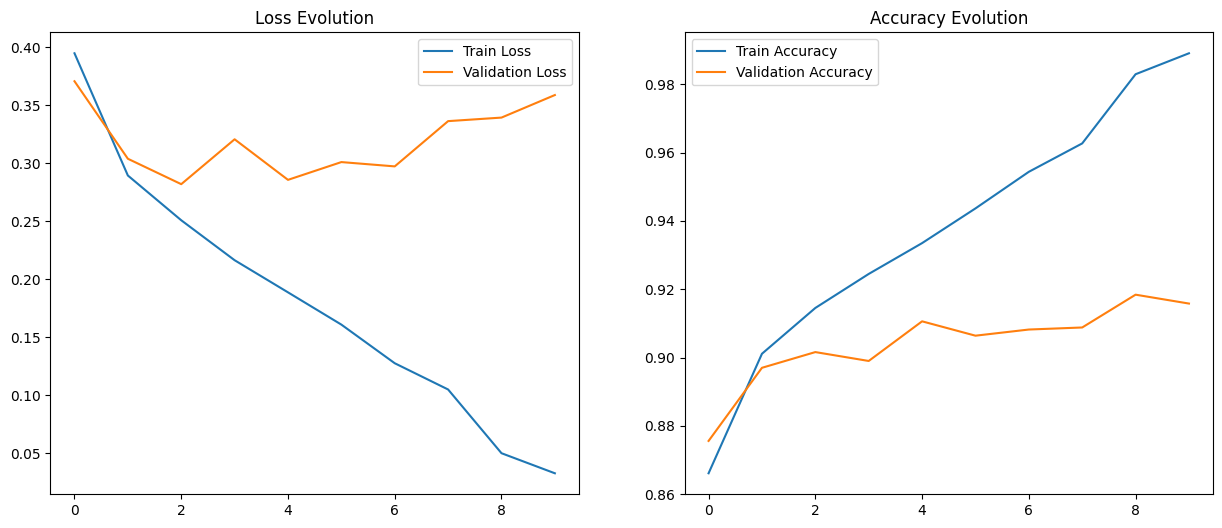

In [85]:
plt.figure(figsize=(15,6))

plt.subplot(1, 2, 1)
plt.plot(model.history.history['loss'], label='Train Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(1, 2, 2)
plt.plot(model.history.history['accuracy'], label='Train Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

In [90]:
model.load_weights('/content/resnet_cifar.weights.h5')
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step
Classification Report:
              precision    recall  f1-score   support

    airplane       0.91      0.94      0.93      1000
  automobile       0.97      0.93      0.95      1000
        bird       0.93      0.89      0.90      1000
         cat       0.76      0.91      0.83      1000
        deer       0.91      0.88      0.90      1000
         dog       0.92      0.83      0.87      1000
        frog       0.97      0.90      0.93      1000
       horse       0.93      0.94      0.93      1000
        ship       0.95      0.96      0.95      1000
       truck       0.93      0.96      0.94      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



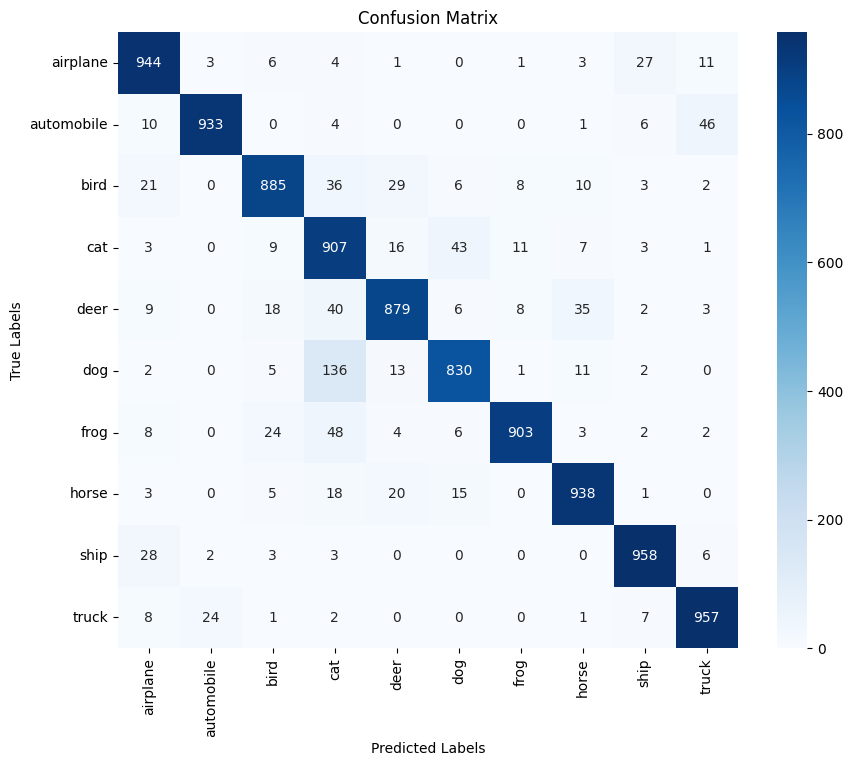

In [91]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.argmax(test_labels, axis=1)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()